In [1]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import numpy as np

load_dotenv()
url = os.getenv("DB_URL")

engine = create_engine(url)

In [2]:
import pandas as pd
orders_df = pd.read_sql_table("orders", engine)
orders_df.head(1)

,id,ticker,class_code,timestamp,side,volume,price,quantity
0,1,SR330CD6A,OPTSPOT,2026-03-23 15:59:24+00:00,BUY,1,0,1


In [3]:
orders_df['timestamp'] = pd.to_datetime(orders_df['timestamp'])
orders_df.set_index('timestamp', inplace=True)
orders_df.sort_index(inplace=True)
orders_df['strike'] = orders_df['ticker'].astype(str).str[2:5]

orders_df.head(1)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-03-23 15:59:24+00:00,1,SR330CD6A,OPTSPOT,BUY,1,0,1,330


In [70]:
large_buy_orders = orders_df[orders_df['side'] == "BUY"].sort_values(by='volume', ascending=False).head(50)
large_buy_orders

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310
2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340
2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310
2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310
2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320
2026-04-17 13:44:19+00:00,6209,SR310CF6,OPTSPOT,BUY,47000,23,2000,310
2026-04-23 12:26:07+00:00,7608,SR320CE6A,OPTSPOT,BUY,43566,10,4322,320
2026-05-05 07:41:17+00:00,10373,SR330CQ6B,OPTSPOT,BUY,38000,7,5000,330
2026-04-22 13:37:36+00:00,7208,SR310CD6E,OPTSPOT,BUY,37584,15,2400,310


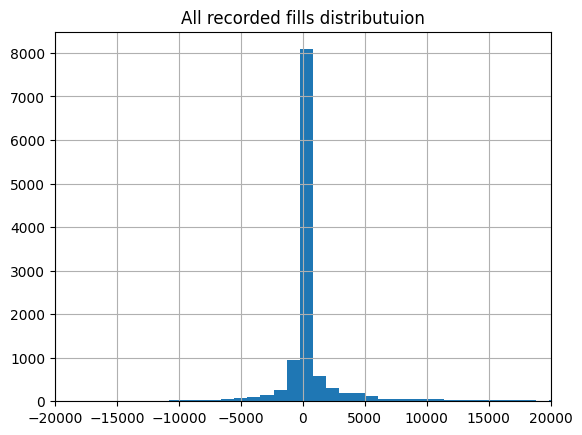

count     11792.000000
mean        456.035448
std        5134.175196
min     -270000.000000
25%         -44.000000
50%          11.000000
75%         241.000000
max      153143.000000
Name: volume, dtype: float64

In [71]:
from matplotlib import pyplot as plt 
hist_df = orders_df.copy()
hist_df.loc[hist_df['side'] == "SELL", 'volume'] *= -1

plt.hist(hist_df['volume'], bins=400)
plt.xlim(-20000, 20000)
plt.grid()
plt.title("All recorded fills distributuion")
plt.show()

hist_df['volume'].describe()

In [72]:
engine = create_engine(url)

orderbooks_df = pd.read_sql("orderbooks", engine)
orderbooks_df.head(1)

,id,ticker,class_code,timestamp,bids,asks,bid_volume,ask_volume
0,959197,SR320CE6A,OPTSPOT,2026-05-04 15:18:06+00:00,"[{'price': 1.33, 'quantity': 800}, {'price': 1...","[{'price': 1.68, 'quantity': 4000}, {'price': ...",136517,11968


In [73]:
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.sort_index(inplace=True)
orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume
timestamp,,,,,,,
2026-03-23 15:39:07+00:00,32159,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1


In [74]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['mid'] = (orderbooks_df['best_ask'] + orderbooks_df['best_bid'])/2

orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume,best_bid,best_ask,mid
timestamp,,,,,,,,,,
2026-03-23 15:39:07+00:00,32159,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1,NaN,0.54,NaN


In [75]:
large_buy_orders['ts_adj'] = large_buy_orders.index + pd.Timedelta(microseconds=1)
df = pd.merge_asof(
    large_buy_orders.reset_index().sort_values('ts_adj'), 
    orderbooks_df[['ticker', 'best_bid', 'best_ask', 'mid']].reset_index(),
    left_on='ts_adj', 
    right_on = 'timestamp',
    by='ticker',
    direction='forward')

df.sort_values("volume", ascending=False).head()

,timestamp_x,id,ticker,class_code,side,volume,price,quantity,strike,ts_adj,timestamp_y,best_bid,best_ask,mid
8,2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310,2026-04-01 10:56:46.000001+00:00,2026-04-01 10:58:55+00:00,8.19,8.50,8.345
49,2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340,2026-05-06 13:48:07.000001+00:00,2026-05-06 13:48:12+00:00,16.25,17.99,17.120
1,2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310,2026-03-25 11:46:13.000001+00:00,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
0,2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310,2026-03-25 06:19:33.000001+00:00,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
40,2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320,2026-04-24 19:06:47.000001+00:00,2026-04-24 19:06:48+00:00,8.77,8.78,8.775


In [76]:
df = df[['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'timestamp_y', 'best_bid', 'best_ask', 'mid']]
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
1,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
2,2026-03-26 15:34:32+00:00,SR320CP6A,26606,4,320,2026-03-26 15:34:40+00:00,4.00,4.71,4.355
3,2026-03-27 09:21:45+00:00,SR270CD6,32473,47,270,2026-03-27 09:22:28+00:00,46.37,47.71,47.040
4,2026-03-27 11:12:23+00:00,SR310CD6,37505,9,310,2026-03-27 11:12:57+00:00,9.46,9.80,9.630


In [77]:
horizons = [5, 30, 60, 120, 480, 720, 1440, 4320, 10080] #minues
#horizons = np.linspace(1, 10080, 20, dtype=int)
print(horizons)
for h in horizons:
    df['time_adj'] = df['timestamp_y'] + pd.Timedelta(minutes=h)
    merged = pd.merge_asof(
        df.sort_values('time_adj'),
        orderbooks_df.reset_index(),
        left_on = 'time_adj',
        right_on = 'timestamp',
        direction = 'nearest',
        tolerance = pd.Timedelta(minutes = h/2),
        by = 'ticker'
    ).sort_index() 
    df[f'best_ask_{h}'] = merged['best_ask_y']
    df[f'best_bid_{h}'] = merged['best_bid_y']
    df[f'mid_{h}'] = merged['mid_y']
    
df.head()

[5, 30, 60, 120, 480, 720, 1440, 4320, 10080]


,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid,time_adj,...,mid_720,best_ask_1440,best_bid_1440,mid_1440,best_ask_4320,best_bid_4320,mid_4320,best_ask_10080,best_bid_10080,mid_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810,2026-04-01 06:19:34+00:00,...,7.665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340,2026-04-01 11:46:14+00:00,...,NaN,11.55,10.70,11.125,NaN,7.89,NaN,10.10,9.09,9.595
2,2026-03-26 15:34:32+00:00,SR320CP6A,26606,4,320,2026-03-26 15:34:40+00:00,4.00,4.71,4.355,2026-04-02 15:34:40+00:00,...,NaN,5.86,5.37,5.615,7.00,NaN,NaN,8.00,0.43,4.215
3,2026-03-27 09:21:45+00:00,SR270CD6,32473,47,270,2026-03-27 09:22:28+00:00,46.37,47.71,47.040,2026-04-03 09:22:28+00:00,...,46.020,NaN,NaN,NaN,46.71,46.37,46.54,47.35,47.01,47.180
4,2026-03-27 11:12:23+00:00,SR310CD6,37505,9,310,2026-03-27 11:12:57+00:00,9.46,9.80,9.630,2026-04-03 11:12:57+00:00,...,NaN,NaN,NaN,NaN,9.50,8.74,9.12,8.87,8.21,8.540


In [78]:
for h in horizons:
    df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']

In [79]:
filtered_df = df.loc[df['strike'].astype(int) > 340]

snr_not_filtered = []
snr_filtered = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    filtered_returns = df.loc[df['strike'].astype(int) > 330][f'mid_price_return_{h}'].dropna()

    print(f"h = {h}, count = {len(returns)}")
    mean = returns.mean()
    std = returns.std()
    snr_not_filtered.append(mean/std)

    mean = filtered_returns.mean()
    std = filtered_returns.std()
    snr_filtered.append(mean/std)

h = 5, count = 36
h = 30, count = 44
h = 60, count = 48
h = 120, count = 47
h = 480, count = 37
h = 720, count = 30
h = 1440, count = 37
h = 4320, count = 33
h = 10080, count = 37


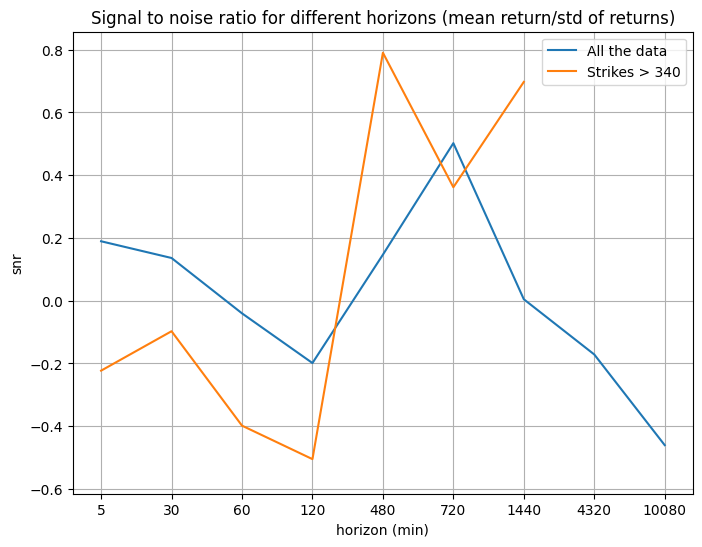

In [80]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), snr_not_filtered, label="All the data")
plt.plot(range(len(horizons)), snr_filtered, label="Strikes > 340")
plt.xticks(range(len(horizons)), horizons)
plt.grid()
plt.title("Signal to noise ratio for different horizons (mean return/std of returns)")
plt.xlabel("horizon (min)")
plt.ylabel("snr")
plt.legend()
plt.show()

In [81]:
stats = pd.DataFrame({
    'mean': [df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std': [df[f'mid_price_return_{h}'].std() for h in horizons],
    'count': [df[f'mid_price_return_{h}'].notna().sum() for h in horizons],
    'mean_otm': [filtered_df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std_otm': [filtered_df[f'mid_price_return_{h}'].std() for h in horizons],
    'count_otm': [filtered_df[f'mid_price_return_{h}'].notna().sum() for h in horizons]
}, index=horizons)
stats

,mean,std,count,mean_otm,std_otm,count_otm
5,0.011281,0.059549,36,-0.002268,0.010173,4
30,0.015797,0.116039,44,-0.001730,0.017787,4
60,-0.004441,0.110349,48,-0.012787,0.043025,4
120,-0.021357,0.107508,47,-0.010546,0.038424,4
480,0.216337,1.474176,37,0.036057,0.045624,3
720,1.870111,3.724672,30,0.024413,0.067507,2
1440,0.000655,0.141490,37,0.060843,0.086275,2
4320,-0.042032,0.245301,33,0.133208,NaN,1
10080,-0.114919,0.249642,37,0.024034,NaN,1


In [82]:
from scipy import stats

rows = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    t_stat, p_value = stats.ttest_1samp(returns, popmean=0)

    rows.append({
        'horizon': h,
        't_stat': t_stat,
        'p_value': p_value
    })

t_test_res = pd.DataFrame(rows)
t_test_res

,horizon,t_stat,p_value
0,5,1.136630,0.263416
1,30,0.903021,0.371546
2,60,-0.278810,0.781614
3,120,-1.361920,0.179856
4,480,0.892651,0.377973
5,720,2.750047,0.010154
6,1440,0.028143,0.977704
7,4320,-0.984324,0.332340
8,10080,-2.800124,0.008163


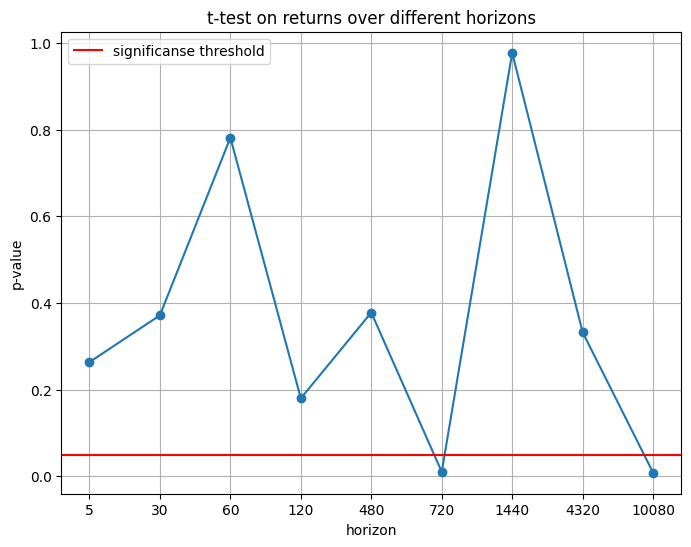

In [83]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), t_test_res['p_value'], marker="o")
plt.xticks(range(len(horizons)), horizons)
plt.xticks()
plt.grid()
plt.xlabel("horizon")
plt.ylabel("p-value")
plt.axhline(0.05, color='red', label="significanse threshold")
plt.title("t-test on returns over different horizons")
plt.legend()
plt.show()

In [84]:
df.columns[0:20]

cols = ['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'best_ask'] + [f'best_bid_{h}' for h in horizons] 
backtest_df = df[cols]

for h in horizons:
    ask = backtest_df[f'best_ask']
    bid = backtest_df[f'best_bid_{h}']
    backtest_df[f'bid_ask_return_{h}'] = (bid - ask)/ask
backtest_df.head(1)

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_5,best_bid_30,best_bid_60,best_bid_120,...,best_bid_10080,bid_ask_return_5,bid_ask_return_30,bid_ask_return_60,bid_ask_return_120,bid_ask_return_480,bid_ask_return_720,bid_ask_return_1440,bid_ask_return_4320,bid_ask_return_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,9.31,8.31,8.09,7.86,7.96,...,NaN,-0.107411,-0.131042,-0.155747,-0.145005,-0.286788,-0.287863,NaN,NaN,NaN


In [85]:
for h in horizons:
    backtest_df[f'equity_{h}'] = backtest_df[f'bid_ask_return_{h}'].cumsum()
backtest_df

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_5,best_bid_30,best_bid_60,best_bid_120,...,bid_ask_return_10080,equity_5,equity_30,equity_60,equity_120,equity_480,equity_720,equity_1440,equity_4320,equity_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,9.31,8.31,8.09,7.86,7.96,...,NaN,-0.107411,-0.131042,-0.155747,-0.145005,-0.286788,-0.287863,NaN,NaN,NaN
1,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,12.68,NaN,12.00,12.00,11.60,...,-0.283123,NaN,-0.184670,-0.209374,-0.230179,-0.371962,-1.286285,-0.156151,-0.377760,-0.283123
2,2026-03-26 15:34:32+00:00,SR320CP6A,26606,4,320,4.71,4.32,4.00,4.00,4.00,...,-0.908705,-0.190214,-0.335413,-0.360117,-0.380922,NaN,NaN,-0.016024,NaN,-1.191828
3,2026-03-27 09:21:45+00:00,SR270CD6,32473,47,270,47.71,47.06,46.54,46.43,46.89,...,-0.014672,-0.203838,-0.359936,-0.386946,-0.398109,-0.408642,-1.325271,NaN,-0.405847,-1.206500
4,2026-03-27 11:12:23+00:00,SR310CD6,37505,9,310,9.80,NaN,NaN,9.70,8.98,...,-0.162245,NaN,NaN,-0.397150,-0.481783,-0.603540,-1.520169,NaN,-0.514010,-1.368745
5,2026-03-31 08:24:20+00:00,SR280CD6,29304,36,280,37.52,36.23,35.85,36.38,36.84,...,0.051173,-0.238220,-0.404446,-0.427534,-0.499906,-0.652580,-1.560680,0.007963,-0.514809,-1.317572
6,2026-04-01 10:40:20+00:00,SR290CD6B,21944,27,290,27.74,NaN,27.58,26.99,27.02,...,0.036770,NaN,-0.410213,-0.454571,-0.525862,-0.683582,-1.626290,-0.020876,-0.591594,-1.280802
7,2026-04-01 10:55:45+00:00,SR290CD6B,22192,27,290,28.04,27.58,27.31,26.99,26.44,...,0.037090,-0.254625,-0.436248,-0.492017,-0.582923,-0.724952,-1.701896,-0.060106,-0.678256,-1.243712
8,2026-04-01 10:56:46+00:00,SR310CD6B,153143,8,310,8.50,NaN,7.52,7.29,7.06,...,0.075294,NaN,-0.551542,-0.634370,-0.752335,-0.797893,NaN,-0.201282,NaN,-1.168418
9,2026-04-02 12:48:49+00:00,SR310CD6,29820,9,310,9.88,9.60,9.60,9.34,9.07,...,0.042510,-0.282965,-0.579882,-0.689026,-0.834318,-0.904168,-1.784892,-0.391566,-0.756191,-1.125908


Text(0, 0.5, 'Equity')

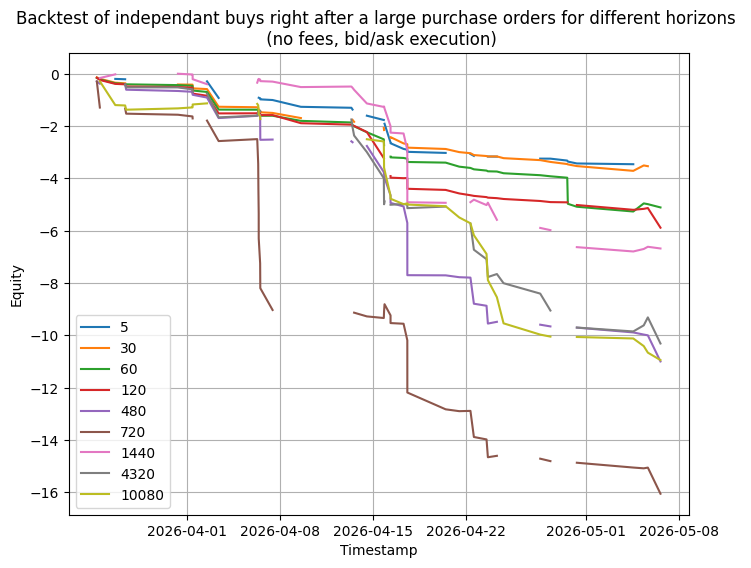

In [86]:
fig = plt.figure(figsize=(8,6))
for h in horizons:
    plt.plot(backtest_df['timestamp_x'], backtest_df[f'equity_{h}'], label=f"{h}")
plt.grid()
plt.legend()
plt.title("Backtest of independant buys right after a large purchase orders for different horizons \n (no fees, bid/ask execution)")
plt.xlabel("Timestamp")
plt.ylabel("Equity")

In [87]:
df_1440 = backtest_df[['timestamp_x', 'bid_ask_return_1440', 'equity_1440']]
df_1440['bid_ask_return_1440'].describe()

count    42.000000
mean     -0.158971
std       0.287676
min      -0.999171
25%      -0.202333
50%      -0.053260
75%       0.019567
max       0.140127
Name: bid_ask_return_1440, dtype: float64

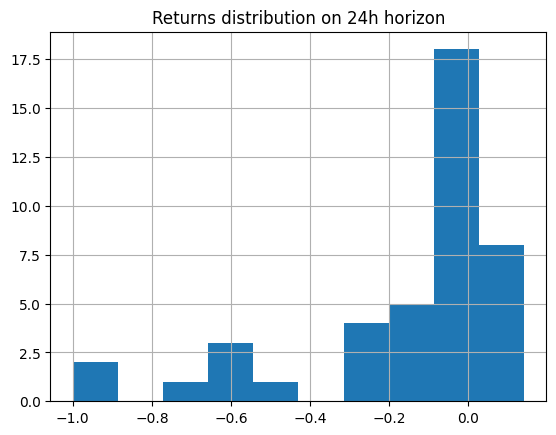

In [90]:
plt.hist(df_1440['bid_ask_return_1440'], bins=10)
plt.grid()
plt.title("Returns distribution on 24h horizon")
plt.show()

In [89]:
wins = (df_1440['bid_ask_return_1440'] > 0).sum() 
losses = (df_1440['bid_ask_return_1440'] < 0).sum() 
wr = (wins)/(wins + losses)
print(wins)
print(losses)
print(wr)

13
29
0.30952380952380953
